<a href="https://colab.research.google.com/github/personallypetra/Grand_Challenge-/blob/Petra/PetraAccenture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture
!rm -rf Grand_Challenge
!git clone https://github.com/personallypetra/Grand_Challenge-.git
%cd Grand_Challenge-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine, inspect

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
import os
print(os.listdir("data_petra"))

['Export-DownloadCenterFile-20260311-234258.xlsx', 'Export-DownloadCenterFile-20260312-012228.xlsx', 'Export-DownloadCenterFile-20260312-012232.xlsx', 'Export-DownloadCenterFile-20260311-234305.xlsx', 'Export-DownloadCenterFile-20260312-012738.xlsx', 'Export-DownloadCenterFile-20260311-234217.xlsx', 'Export-DownloadCenterFile-20260311-234315.xlsx', 'Export-DownloadCenterFile-20260311-234227.xlsx', 'Export-DownloadCenterFile-20260312-012253.xlsx', 'Export-DownloadCenterFile-20260311-234252.xlsx', 'Export-DownloadCenterFile-20260312-012235.xlsx']


# Loading **Consumption** datasets and merging them into one csv file

In [4]:
%%capture
df1 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260311-234217.xlsx")
df2 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260311-234227.xlsx")
df3 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260311-234252.xlsx")
df4 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260311-234258.xlsx")
df5 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260311-234305.xlsx")
df6 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260311-234315.xlsx")

In [5]:
%%capture
df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index = True)
df.to_csv("Total_Load_Full.csv", index=False)
df = pd.read_csv("Total_Load_Full.csv")


### Checking shape and head

In this step, we are going to check the data inside our csv file to gain some insights.

In [6]:
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1453829, 4)
                  Date  Total Load [MW]  Forecast Total Load [MW]  \
0  2025-12-31 23:45:00          756.471                   716.480   
1  2025-12-31 23:45:00         2355.485                  2230.962   
2  2025-12-31 23:45:00         4681.805                  4434.301   
3  2025-12-31 23:45:00        13788.973                 13060.018   
4  2025-12-31 23:45:00          865.022                   819.293   

   Bidding Zone  
0      Calabria  
1  Centre-North  
2  Centre-South  
3         North  
4      Sardinia  
['Date', 'Total Load [MW]', 'Forecast Total Load [MW]', 'Bidding Zone']


## Creating new csv file that contains daily consumption


The available database measures total load and forecast Total Load each 15 minutes. We are now creating new database that is going to contain same informations on daily basis.

In [7]:
df.columns  = df.columns.str.strip()
df["Bidding Zone"] = df["Bidding Zone"].astype(str).str.strip()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

DailyConsumption = (df.groupby([
    pd.Grouper(key = "Date", freq = "D"), "Bidding Zone"])
    ["Total Load [MW]"].mean().reset_index())


### Creating wider table with dates as rows and regional consumptions of electricity as columns

By doing this we are gaining clearer view of our data.

In [8]:
DailyConsumption_Wide = DailyConsumption.pivot(index = "Date", columns = "Bidding Zone", values = "Total Load [MW]").reset_index()
DailyConsumption.to_csv("DailyConsumption.csv", index = False)
DailyConsumption_Wide.to_csv("DailyConsumption_Wide.csv", index = False)

DailyConsumption_Wide.columns.name = None
print(DailyConsumption_Wide.head())


        Date    Calabria  Centre-North  Centre-South         Italy  \
0 2021-01-01  592.586505   2353.797260   4779.609458  25509.468729   
1 2021-01-02  626.306281   2478.478625   5197.343031  27544.197896   
2 2021-01-03  627.480115   2342.853312   5065.761927  26613.031198   
3 2021-01-04  733.124813   2969.801635   6072.452698  33755.541667   
4 2021-01-05  722.009979   3163.967812   6471.392354  35059.562646   

          North     Sardinia       Sicily        South  
0  12720.334229  1008.967958  1957.947396  2102.398698  
1  13923.800177  1045.211010  2100.798208  2172.260563  
2  13400.244250  1036.130698  2041.380677  2099.180219  
3  17876.990146  1109.121469  2263.508875  2730.542031  
4  18798.909760  1129.786948  2118.167458  2655.328333  


In [9]:
print(df["Date"].min())
print(df["Date"].max())

2021-01-01 00:00:00
2026-03-10 23:45:00


## Checking for missing values if any

Before plotting, we would like to know if we are missing any consumption data. Moreover, if so, we would like to locate it and see what is the best way to overcome that issue.

In [10]:
DailyConsumption_Wide["Date"] = pd.to_datetime(DailyConsumption_Wide["Date"])

full_dates = pd.date_range(
    start = DailyConsumption_Wide["Date"].min(),
    end = DailyConsumption_Wide["Date"].max(),
    freq = "D"
)

missing_dates = full_dates[~full_dates.isin(DailyConsumption_Wide["Date"])]
print(missing_dates)
print(DailyConsumption_Wide.isna().sum())

DatetimeIndex(['2026-01-14', '2026-01-15'], dtype='datetime64[ns]', freq='D')
Date            0
Calabria        0
Centre-North    0
Centre-South    0
Italy           0
North           0
Sardinia        0
Sicily          0
South           0
dtype: int64


Based on this results, we can conclude that there are two days missing (14th and 15th January 2026). Furthermore, there are no missing values for any other day present in any of regions.



---
## Checking for Duplicates

One more step before we proceed with plotting our data. We don't expect any duplicates, but better to be safe than sorry.



In [11]:
print("Duplicate dates:", DailyConsumption_Wide["Date"].duplicated().sum())

Duplicate dates: 0


## Plotting Consumption data


---

We are going to make 2 plots – one with each region's consumption and one for the whole Italy.


---
### Regional Consumption


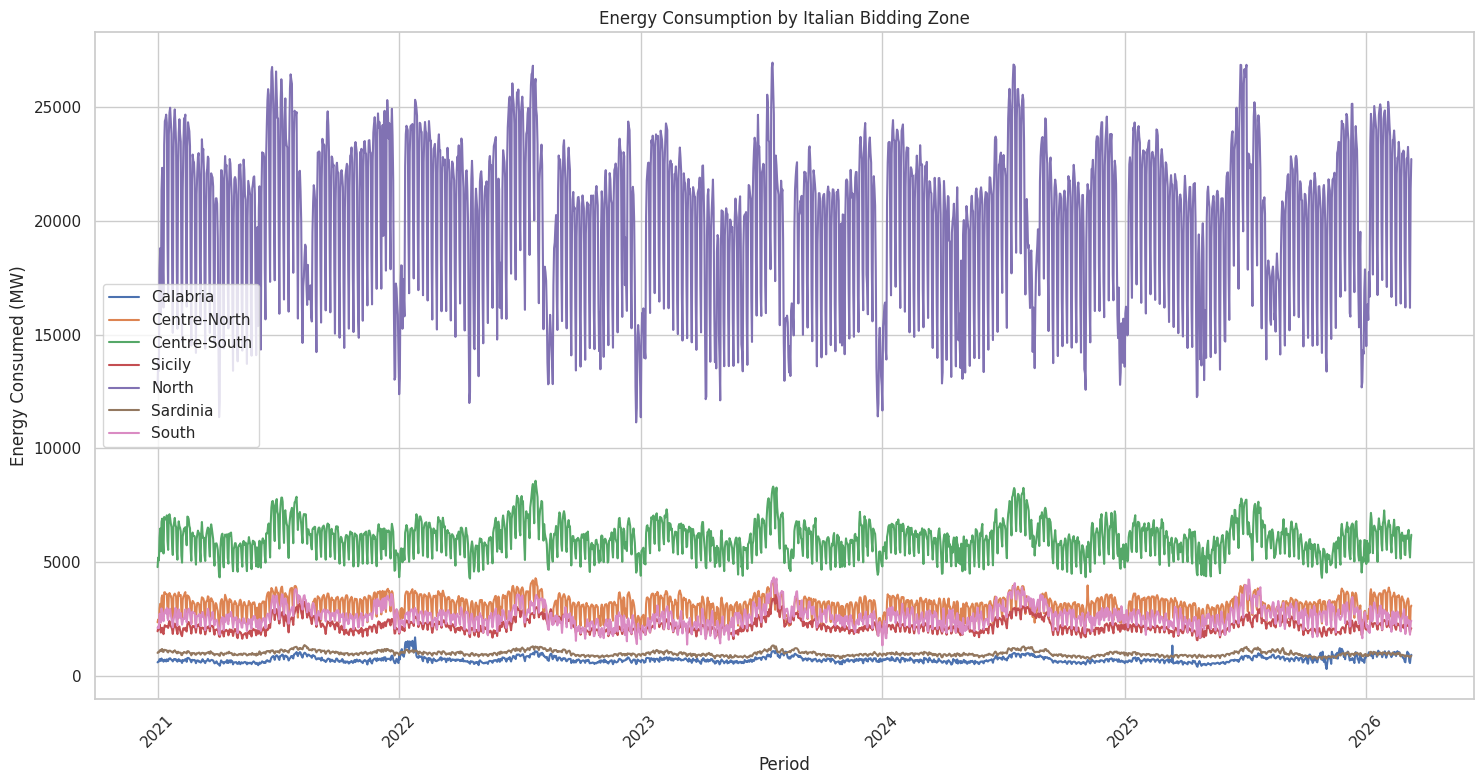

In [12]:
plt.figure(figsize=(15, 8))
regions = [
    "Calabria",
    "Centre-North",
    "Centre-South",
    "Sicily",
    "North",
    "Sardinia",
    "South"
]

for region in regions:
  plt.plot(DailyConsumption_Wide["Date"], DailyConsumption_Wide[region], label=region)

plt.xlabel("Period")
plt.ylabel("Energy Consumed (MW)")
plt.title("Energy Consumption by Italian Bidding Zone")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph illustrates the electricity consumption by each region. `North` region shows constantly biggest consumption of electricity, whereas, region `Calabria` remains (almost) constantly the lowest consumption region.


---
### Italy's Consumption




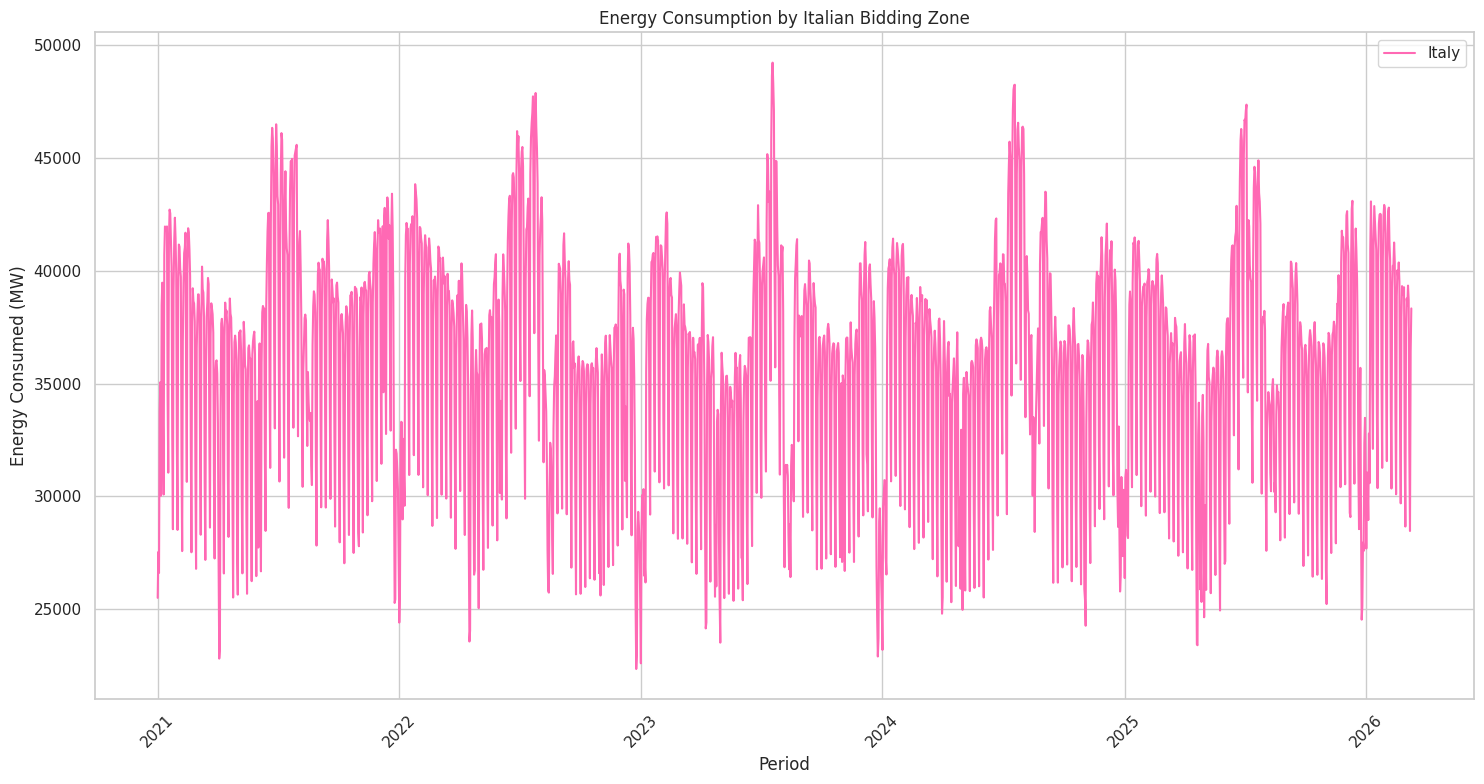

In [13]:
plt.figure(figsize=(15, 8))

plt.plot(DailyConsumption_Wide["Date"], DailyConsumption_Wide["Italy"], label="Italy", color = "#FF69B4")

plt.xlabel("Period")
plt.ylabel("Energy Consumed (MW)")
plt.title("Energy Consumption by Italian Bidding Zone")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph shows the daily electricity consumption in Italy. Overall, demand fluctuates significantly. However it follows clear seasonal trend, that includes:
- peaks close to 49000 MW;
- lows around 23000 - 26000 MW.

Aside short-term variations, the general level seems to be stable over time.

---
# Loading **Energy Production** datasets and merging them


In [14]:
%%capture
df1 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260312-012228.xlsx")
df2 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260312-012232.xlsx")
df3 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260312-012235.xlsx")
df4 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260312-012253.xlsx")
df5 = pd.read_excel("data_petra/Export-DownloadCenterFile-20260312-012738.xlsx")


In [15]:
df = pd.concat([df1, df2, df3, df4, df5], ignore_index  = True)
df.to_excel("Energy_Production.xlsx", index = False)
df.head()

,Date,Actual Generation,Primary Source
0,2024-12-31 23:00:00,15.210,Thermal
1,2024-12-31 23:00:00,1.740,Hydro
2,2024-12-31 23:00:00,0.600,Geothermal
3,2024-12-31 23:00:00,0.000,Photovoltaic
4,2024-12-31 23:00:00,2.233,Self-consumption


In [35]:
df = df[~df["Date"].astype(str).str.contains("Applied filters", na=False)].copy()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

DailyEnergyProduction = (
    df.assign(Day=df["Date"].dt.floor("D"))
      .groupby(["Day", "Primary Source"], as_index=False)["Actual Generation"]
      .mean()
)

print(DailyEnergyProduction["Day"].min())
print(DailyEnergyProduction["Day"].max())

2021-01-01 00:00:00
2025-12-31 00:00:00


## Finding unique sources

In this part, we are going to find our key primary sources of electrical energy generators.  

In [36]:
print((DailyEnergyProduction["Primary Source"]).unique())

['Geothermal' 'Hydro' 'Photovoltaic' 'Self-consumption' 'Thermal' 'Wind']


In [37]:
print(DailyEnergyProduction["Day"].min())
print(DailyEnergyProduction["Day"].max())

2021-01-01 00:00:00
2025-12-31 00:00:00


Our data set covers the period from 1st January 2021 to 31st December 2025



Since the data above covers the Lazio Region, in order to see how much of the consumed energy came from the previously mentioned sources, we are going to extract data from 'TotalDailyLoad' about 'Centre-South' region.


### Adjusting 2025 to rest of the dataset values


---



In [42]:
DailyEnergyProduction["Day"] = pd.to_datetime(DailyEnergyProduction["Day"])

df_2024 = DailyEnergyProduction[
    (DailyEnergyProduction["Day"] >= "2024-01-01") &
    (DailyEnergyProduction["Day"] <= "2024-01-05")
]

df_2025 = DailyEnergyProduction[
    (DailyEnergyProduction["Day"] >= "2025-01-01") &
    (DailyEnergyProduction["Day"] <= "2025-01-05")
]
print(DailyEnergyProduction["Day"].min())
print(DailyEnergyProduction["Day"].max())
print(DailyEnergyProduction["Day"].head())

mean_2024 = df_2024.groupby("Primary Source")["Actual Generation"].mean()
print(mean_2024)
mean_2025 = df_2025.groupby("Primary Source")["Actual Generation"].mean()
print(mean_2025)

2021-01-01 00:00:00
2025-12-31 00:00:00
0   2021-01-01
1   2021-01-01
2   2021-01-01
3   2021-01-01
4   2021-01-01
Name: Day, dtype: datetime64[ns]
Primary Source
Geothermal           0.626333
Hydro                3.665000
Photovoltaic         1.084000
Self-consumption     2.002833
Thermal             11.904417
Wind                 4.434583
Name: Actual Generation, dtype: float64
Primary Source
Geothermal           0.611083
Hydro                3.467667
Photovoltaic         1.527167
Self-consumption     2.381692
Thermal             13.632500
Wind                 2.591750
Name: Actual Generation, dtype: float64


In [43]:
energy_plt = DailyEnergyProduction.pivot(
    index="Day",
    columns="Primary Source",
    values="Actual Generation"
).reset_index()
energy_plt["Total"] = energy_plt[["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]].sum(axis = 1)
energy_plt["Media"] = energy_plt[["Geothermal", "Hydro", "Photovoltaic", "Self-consumption", "Thermal", "Wind"]].mean(axis = 1)


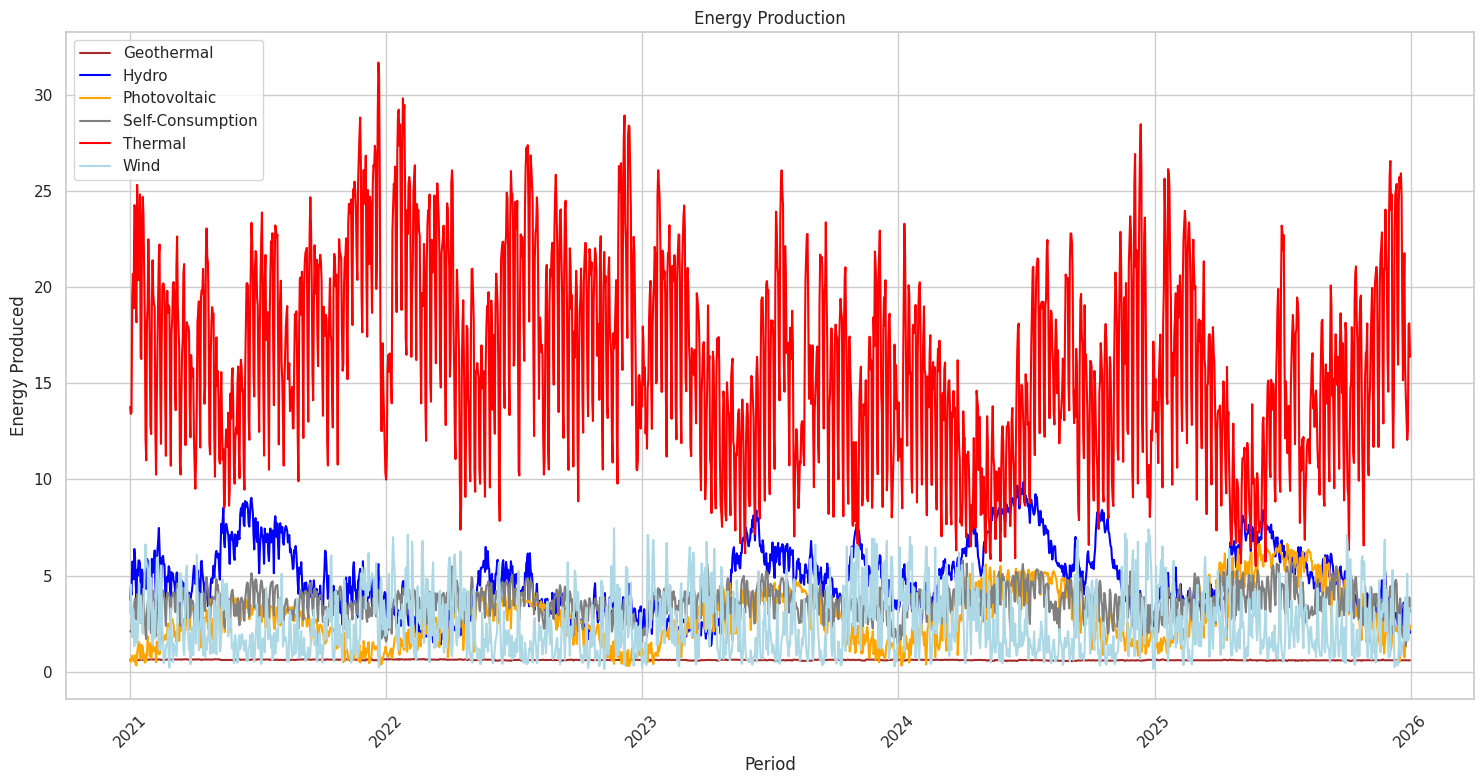

In [45]:
plt.figure(figsize = (15, 8))

plt.plot(energy_plt["Day"], energy_plt["Geothermal"], color = "brown", label = "Geothermal")
plt.plot(energy_plt["Day"], energy_plt["Hydro"], color = "blue", label = "Hydro")
plt.plot(energy_plt["Day"], energy_plt["Photovoltaic"], color = "orange", label = "Photovoltaic")
plt.plot(energy_plt["Day"], energy_plt["Self-consumption"], color = "grey", label = "Self-Consumption")
plt.plot(energy_plt["Day"], energy_plt["Thermal"], color = "red", label = "Thermal")
plt.plot(energy_plt["Day"], energy_plt["Wind"], color = "lightblue", label = "Wind")


plt.xlabel("Period")
plt.ylabel("Energy Produced")
plt.title("Energy Production")
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()